# NDLArEventDisplay Example -- COPY ME

#### LArEventDisplay is the ND LAr+TMS event display class defined in ndlar_evd.py. For scanning through events, please make a copy of this notebook to use and update locally. Please DO NOT commit changes to this example notebook.

In [1]:
# Commentd because these features are not fully implemented yet
#!pip install ipympl
#%matplotlib widget

import sys
# Change below to match your path to ndlar_flow/event_display/LAr_evd
sys.path.append('/your/path/to/ndlar_flow/event_display/LAr_evd/')
from ndlar_evd import *
plt.ion()

Hello


#### Inputs to LArEventDisplay:

- `filedir`       (str): path to input file
- `filename`      (str): name of file; must be flow file
- `nhits_min`        (int): minimum number of hits (threshold) for events to be made available (default: 1)
- `nhits_max`        (int): maximum number of hits allowed in event for events to be made available (default: 1e10)
- `ntrigs`        (int): minimum number of external triggers required for events to be made available in interactive display (default=0)
- `show_light`    (bool): whether to show light information in display (default: True, but this takes longer to run) - only relevant for 2x2
- `show_colorbars`(bool): if True, shows color bars for charge and light information in 2x2 (default: True)
- `filepath_tms`  (str): TMS file (include full file path) associated with input flow file (default: None). For the moment, truth information from the TMS reco file are used. Please note that TMS and ND-LAr matching is still a work in progress.
- `charge_threshold` (float): threshold for charge hits to be shown (default: None)
- `light_threshold` (float): threshold for light to be shown (default: 150000 ADC counts)
- `beam_only`       (bool): whether to only show beam events (default: False) - only relevant for 2x2
- `hist_projection` (bool): if True, hits are binned in a 2D histogram for the 2D charge hit projections. Bins with 0 charge are not displayed. If False, hits are plotted as scatter points for the 2D charge hit projections. For the histograms, sizes are the same for beam, drift, and vertical axes even though drift coordinate resolution may be finer than the resolution in beam/vertical (pixel) dimensions. While binning covers the spaces between modules, it does not cover space external to the modules (only expected for unphysical detector responses or in the case of an event building bug.) (default: True)
- `single_neutrino` (bool): if True, when using files containing one neutrino per spill. Use False for files containing full spills.

Please note that whether `hist_projection` is True or False, all histogram bins and/or points in all plots (2D and 3D) are slightly larger than pixel pitch-sized by default. This is because the interactive viewer is unable to clearly resolve points/bins reflecting the pixel pitch. However, if you would like to see an event where all points ARE scaled to (approximately) pixel pitch, you can save a PDF version of the event display in which the histogram bins and/or points do reflect pixel pitch using the `p`+`Enter` option described below.

In [2]:
# This set of inputs allows you to look at a data file from the sandbox
# These data do NOT include light information, so please do not set "show_light" to True
d = '/your/path/to/flow/files/'
f='MicroProdN4p1_NDComplex_FHC.flow.full.light.0002459.FLOW.hdf5'

# Uncomment to look at TMS file
tms_dir = '/your/path/to/TMS/files/'
tms_filename = 'MicroProdN4p1_NDComplex_FHC.tmsreco.full.0002459.TMSRECO.root'
#tms_file = tms_dir + tms_filename
tms_file = None # Comment out if you want to look at above TMS file

single_neutrino=False

#### Running the following cell will show the event display and a user input box. User input options are:

 - `q`+`Enter`       : quit the event display
 - `s`+`Enter`       : save current event display to a PDF
 - `p`+`Enter`       : save current event display to a PDF with points scaled to pixel pitch
 - `g`+`Enter`       : create GIF from current event display (only 3D LAr-only display will be animated). Please note that this takes a long time (potentially ~30 minutes). 
 - `Enter` : proceed to the next available event
 - `n`+`Enter` : proceed to the Event `n` if available (Event `n` may not be available, especially if `nhits` > 1. If this is the case, the display will instead proceed to next available event).

Number of external triggers in this event: 1
0 196164
 
Event 0 is NOT a beam trigger event


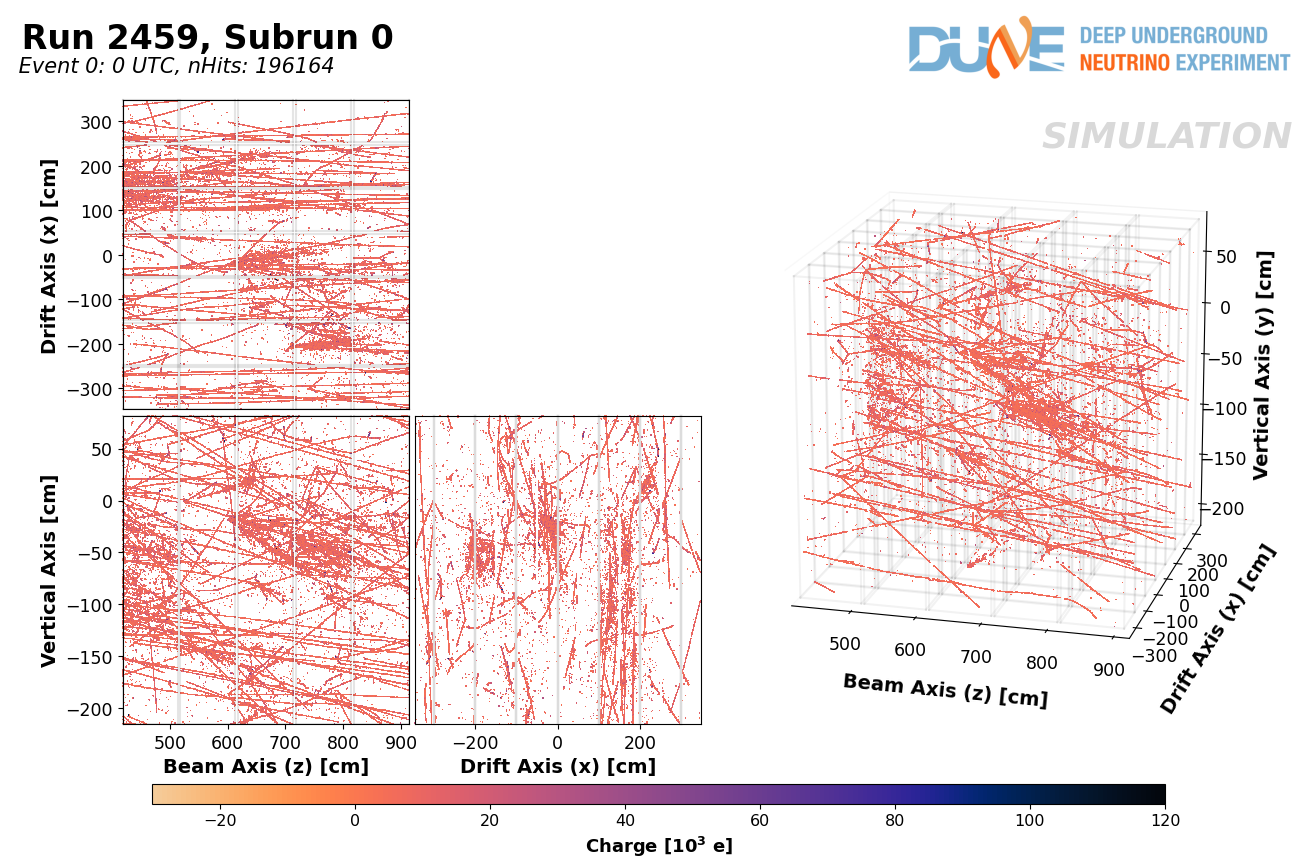

In [ ]:
evd = LArEventDisplay(filedir=d, filename=f, nhits_min=1, ntrigs=0, show_light=False, show_colorbars=False, hist_projection=False, filepath_tms=tms_file, single_neutrino=single_neutrino)
evd.run()
